In [1]:
import pandas as pd
import numpy as np 

In [2]:
np.random.seed(42)

In [3]:
# to generate the random datasets  for the defects 
n_sample = 700

pH_level = np.random.uniform(6.5, 7.5, n_sample)   #ph level
mixing_time = np.random.randint(20, 60, n_sample)   #minutes
cooling_rate = np.random.uniform(4.0, 6.0, n_sample) # °C/min
impurity_percentage = np.random.uniform(0.0, 1.0, n_sample) # %

# Adding the defects rule 
defects_prob = (
    0.5 * impurity_percentage +
    0.3 * (cooling_rate > 5.5 ).astype(int) +
    0.25 * (pH_level < 6.8).astype(int)
)

defects = (np.random.rand(n_sample) > defects_prob).astype(int)

dataframe = {
    'pH_level' : pH_level,
    'mixing_time' : mixing_time,
    'cooling_rate' : cooling_rate,
    'impurity_percentage' : impurity_percentage,
    "defects" : defects
}

material_data = pd.DataFrame(dataframe)

print(material_data.head(10))


   pH_level  mixing_time  cooling_rate  impurity_percentage  defects
0  6.874540           22      4.370918             0.235858        0
1  7.450714           52      4.924195             0.371422        1
2  7.231994           25      4.002464             0.062542        1
3  7.098658           29      5.196655             0.801367        0
4  6.656019           24      5.214613             0.766589        1
5  6.655995           42      4.495080             0.733616        0
6  6.558084           29      5.116825             0.299444        1
7  7.366176           21      4.451080             0.173480        1
8  7.101115           32      4.321651             0.637553        1
9  7.208073           59      5.303039             0.496166        1


In [4]:
print(material_data['defects'].value_counts())

defects
1    438
0    262
Name: count, dtype: int64


In [5]:
print(material_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pH_level             700 non-null    float64
 1   mixing_time          700 non-null    int32  
 2   cooling_rate         700 non-null    float64
 3   impurity_percentage  700 non-null    float64
 4   defects              700 non-null    int64  
dtypes: float64(3), int32(1), int64(1)
memory usage: 24.7 KB
None


In [6]:
print(material_data.describe())

         pH_level  mixing_time  cooling_rate  impurity_percentage     defects
count  700.000000   700.000000    700.000000           700.000000  700.000000
mean     6.992814    40.237143      4.985678             0.499846    0.625714
std      0.295001    11.666481      0.556027             0.293916    0.484284
min      6.505062    20.000000      4.000665             0.000188    0.000000
25%      6.737540    30.000000      4.491178             0.238339    0.000000
50%      7.002658    41.000000      5.010952             0.500362    1.000000
75%      7.250679    51.000000      5.448587             0.757718    1.000000
max      7.499718    59.000000      5.990961             0.999714    1.000000


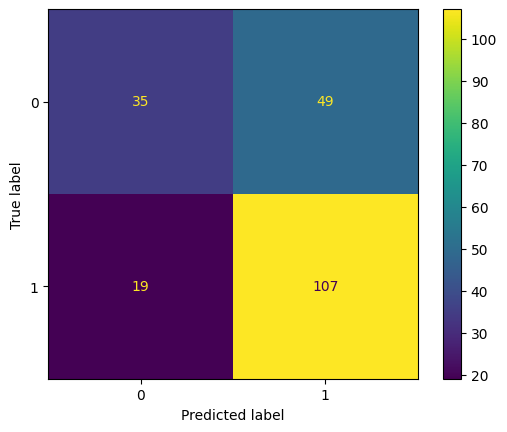

the Models parameters [[ 35  49]
 [ 19 107]]
              precision    recall  f1-score   support

           0       0.65      0.42      0.51        84
           1       0.69      0.85      0.76       126

    accuracy                           0.68       210
   macro avg       0.67      0.63      0.63       210
weighted avg       0.67      0.68      0.66       210



In [7]:
#  model inspection
from sklearn.linear_model import LogisticRegression
from sklearn.metrics  import classification_report, confusion_matrix, precision_recall_curve, auc, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 

X = material_data[['pH_level', 'mixing_time', 'cooling_rate', 'impurity_percentage']]
y = material_data['defects']

model = LogisticRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size= 0.3)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.savefig("Materials_defects_display.png")
plt.show()

print(f'the Models parameters', cm)
print(classification_report(y_test, y_pred))


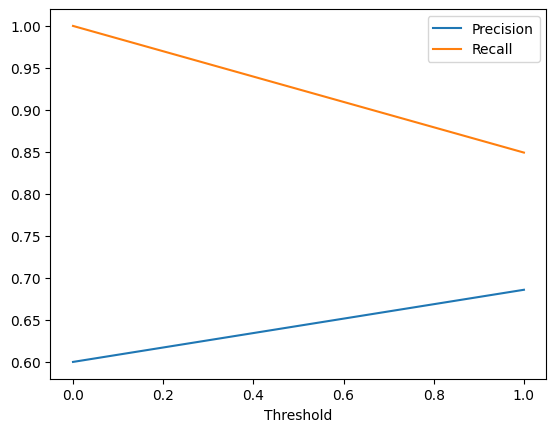

In [8]:
# plotting the presccision recall curve 
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel("Threshold")
plt.legend()
plt.show()

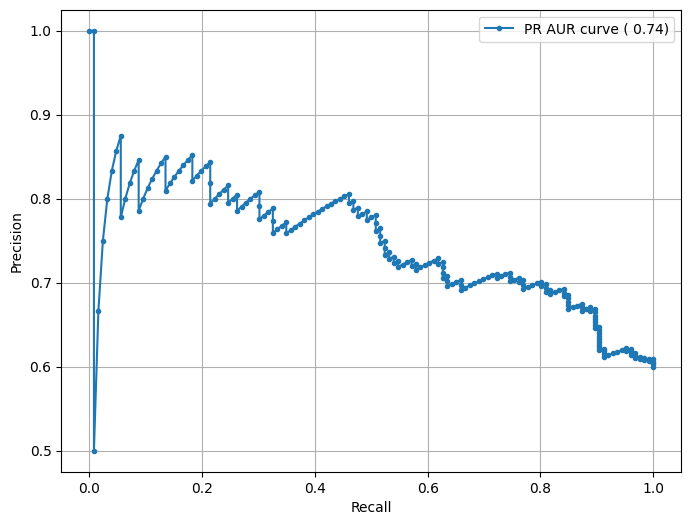

In [9]:
y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
 
area_under_curve = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR AUR curve ({area_under_curve: .2f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.savefig('precision_recall_curve.png')
plt.legend()
plt.show()


In [10]:
# printing my model parameters 
coefficients = model.coef_[0]
intercept = model.intercept_[0]

for feature, coef in zip(X.columns, coefficients):
    print(f'{feature} : { coef: .4f}')

print('Intercept', intercept)

pH_level :  0.8791
mixing_time : -0.0126
cooling_rate : -1.0006
impurity_percentage : -2.5837
Intercept 1.3262329140473827


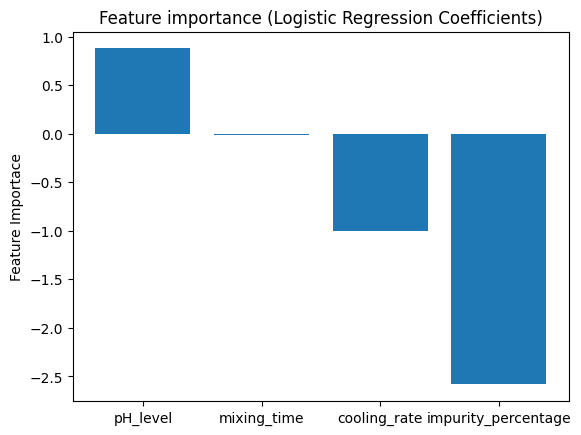

In [12]:
# plotting a bar graph to see which feature dominates
plt.bar(X.columns, coefficients)
plt.title('Feature importance (Logistic Regression Coefficients)')
plt.ylabel("Feature Importace")
plt.savefig('Bar Logistic Regression Coefficients')
plt.show()

In [17]:
# to save my generated data to a csv file
material_data.to_csv("material_defects_data.csv", index=False)

In [14]:
import joblib

joblib.dump(model, 'material_data_model.pkl')


['material_data_model.pkl']

In [16]:
# export my models performance as a jsonfile
import json 

cm = confusion_matrix(y_test, y_pred).tolist()

cr = classification_report(y_test, y_pred, output_dict=True)

performance = {
    'Confusion_matrix' : cm,
    "Classification_report" : cr
}

with open("model_performance.json", 'w') as f:
    json.dump(performance, f)